In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data1 = pd.read_csv('/content/drive/MyDrive/DataSets/Walmart DataSet.csv')
data1.set_index('Date', inplace=True)
# There are about 45 different stores in this dataset. Lets select the any store id from 1-45
a= int(input("Enter the store id:"))
store = data1[data1.Store == a]
sales = pd.DataFrame(store.Weekly_Sales.groupby(store.index).sum())
sales.dtypes

Enter the store id:21


,0
Weekly_Sales,float64


In [ ]:
sales.head(20)

,Weekly_Sales
Date,
01-04-2011,732056.37
01-06-2012,695439.83
01-07-2011,784639.12
01-10-2010,677158.39
02-03-2012,764385.40
02-04-2010,753664.12
02-07-2010,711470.80
02-09-2011,705557.80
02-12-2011,793184.25


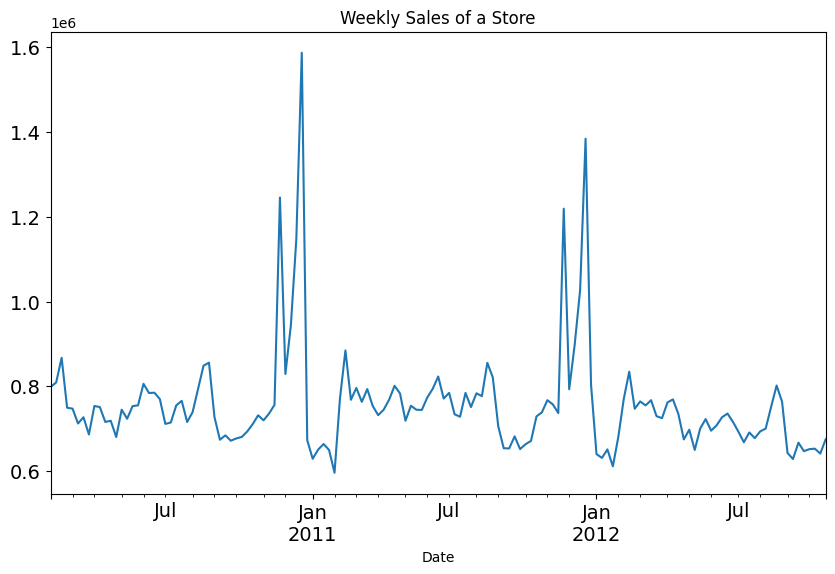

In [ ]:
sales.reset_index(inplace=True)
sales['Date'] = pd.to_datetime(sales['Date'], dayfirst=True)
sales.set_index('Date', inplace=True)
sales.sort_index(inplace=True)

sales['Weekly_Sales'].plot(figsize=(10,6), title='Weekly Sales of a Store', fontsize=14)
plt.show()

<Figure size 640x480 with 0 Axes>

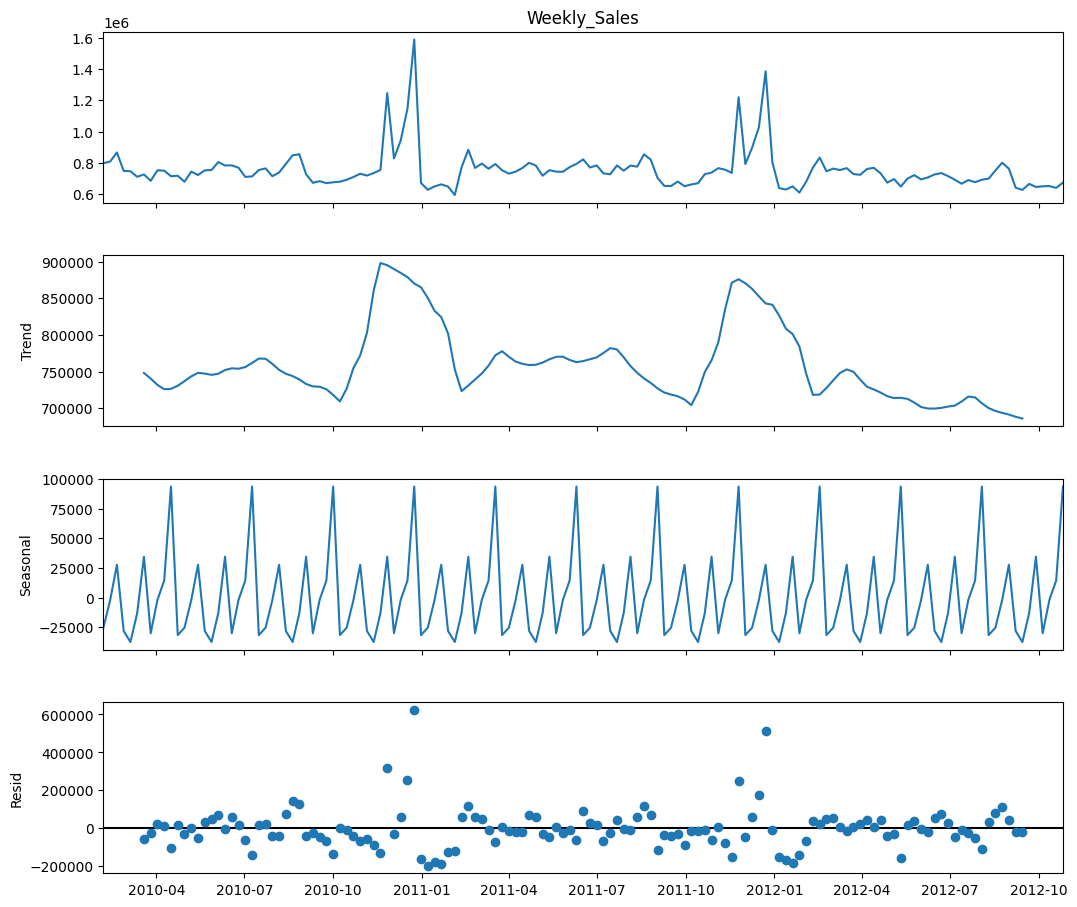

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(sales.Weekly_Sales, period=12)
fig = plt.figure()
fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.show()

In [ ]:
#data comparison between two stores

#taking 5 stores for analysis
store5 = data1[data1.Store == 5]
sales5 = pd.DataFrame(store5.Weekly_Sales.groupby(store5.index).sum())
sales5.dtypes

#remove the date from index and change its datatype
sales5.reset_index(inplace=True)
sales5['Date'] = pd.to_datetime(sales5['Date'], dayfirst=True)
sales5.set_index('Date', inplace=True)
sales5.sort_index(inplace=True)

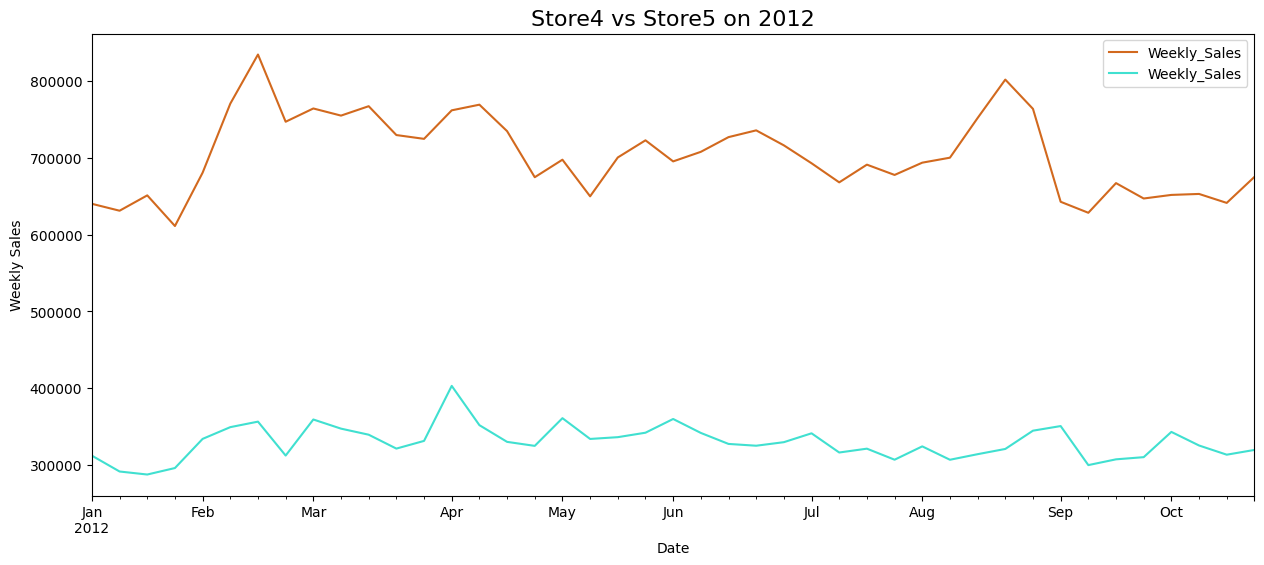

In [ ]:
y1=sales.Weekly_Sales
y2=sales5.Weekly_Sales
y1['2012'].plot(figsize=(15, 6),legend=True, color = 'chocolate')
y2['2012'].plot(figsize=(15, 6), legend=True, color = 'turquoise')
plt.ylabel('Weekly Sales')
plt.title('Store4 vs Store5 on 2012', fontsize = '16')
plt.show()

In [ ]:
#irregularities spotted
#take var p,d,q to take random val between [0,2]
p = d = q = range(0, 5)
import itertools

#gen all pdq triplets comb.
pdq = list(itertools.product(p, d, q))

#generate combs of seasonal pdq triplets
seasonal_pdq = [(x[0], x[1], x[2], 52) for x in list(itertools.product(p, d, q))]

In [ ]:
import statsmodels.api as sm

mod = sm.tsa.statespace.SARIMAX(y1,
                                order=(4, 4, 3),
                                seasonal_order=(1, 1, 0, 52),   #enforce_stationarity=False,
                                enforce_invertibility=False)

results = mod.fit()

print(results.summary().tables[1])

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.1115      0.900     -1.235      0.217      -2.875       0.653
ar.L2         -0.8144      0.795     -1.024      0.306      -2.373       0.744
ar.L3         -0.3931      0.450     -0.873      0.383      -1.276       0.489
ar.L4         -0.1886      0.147     -1.281      0.200      -0.477       0.100
ma.L1         -1.7052      0.907     -1.879      0.060      -3.484       0.073
ma.L2          0.4817      1.810      0.266      0.790      -3.065       4.029
ma.L3          0.2295      0.928      0.247      0.805      -1.590       2.049
ar.S.L52      -0.2396      0.059     -4.046      0.000      -0.356      -0.124
sigma2      6.847e+09   2.85e-10    2.4e+19      0.000    6.85e+09    6.85e+09


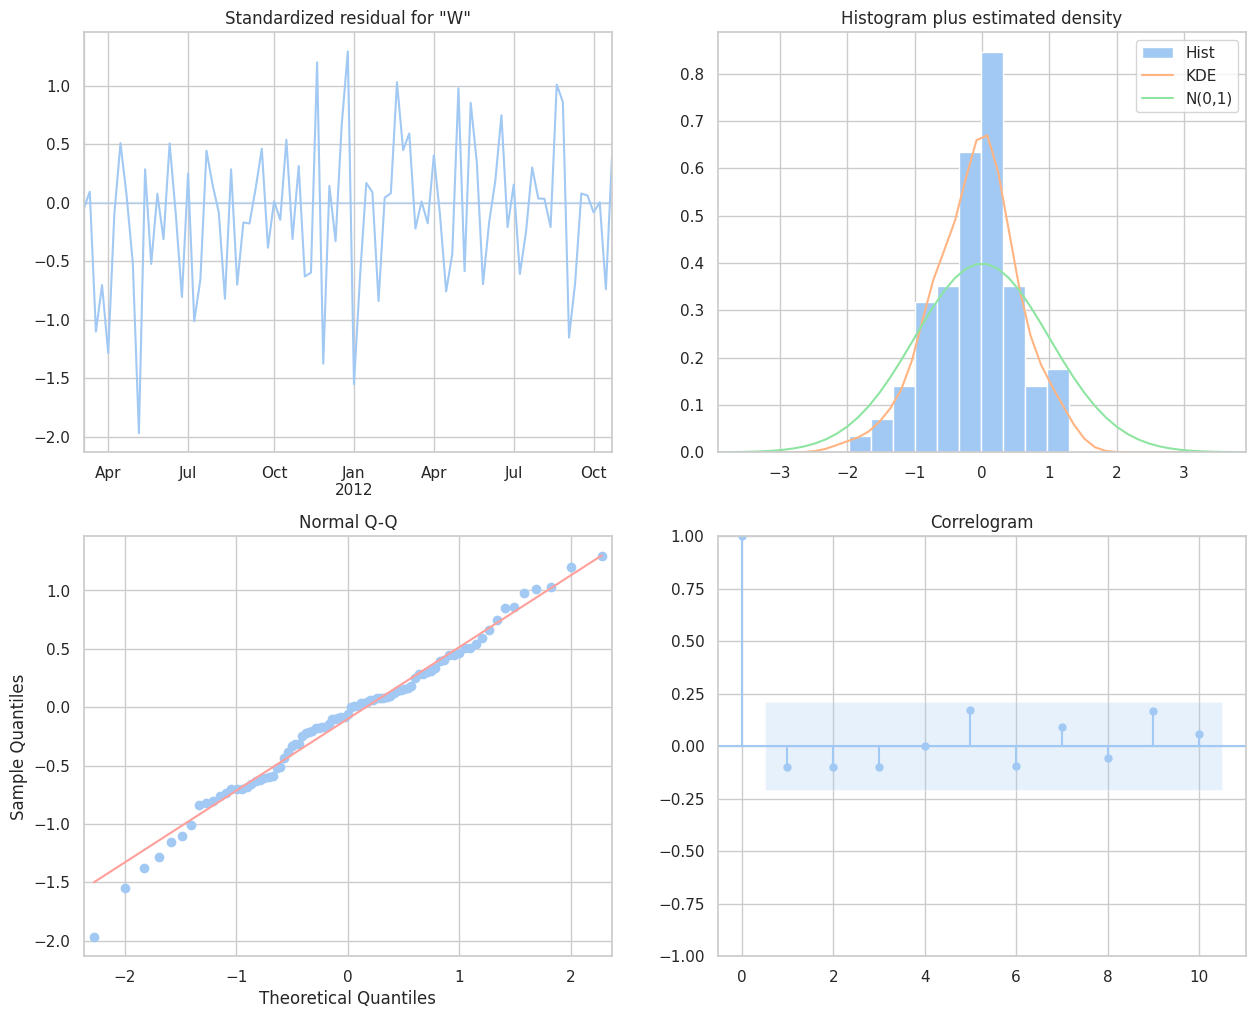

In [ ]:
import seaborn as sns

sns.set_theme(style="whitegrid", palette="pastel")

results.plot_diagnostics(figsize=(15, 12))
plt.show()

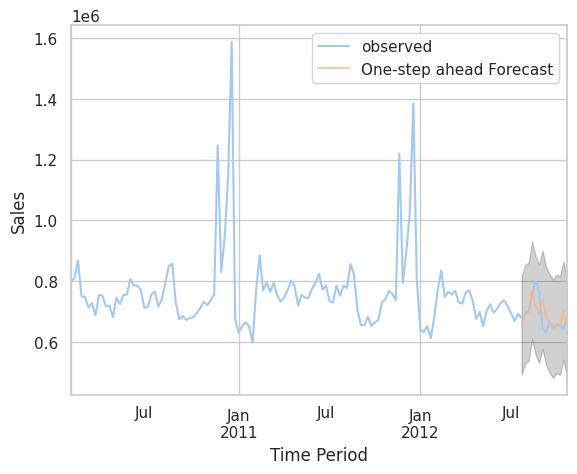

In [ ]:
pred = results.get_prediction(start=pd.to_datetime('2012-07-27'), dynamic=False)
pred_ci = pred.conf_int()
ax = y1['2010':].plot(label='observed')
pred.predicted_mean.plot(ax=ax, label='One-step ahead Forecast', alpha=.7)

ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.2)

ax.set_xlabel('Time Period')
ax.set_ylabel('Sales')
plt.legend()

plt.show()

In [ ]:
y_forecasted = pred.predicted_mean
y_truth = y1['2012-7-27':]

# Compute the mean square error
mse = ((y_forecasted - y_truth) ** 2).mean()
print('The Mean Squared Error of our forecasts is {}'.format(round(mse, 2)))

The Mean Squared Error of our forecasts is 2154398383.39


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['full_results']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


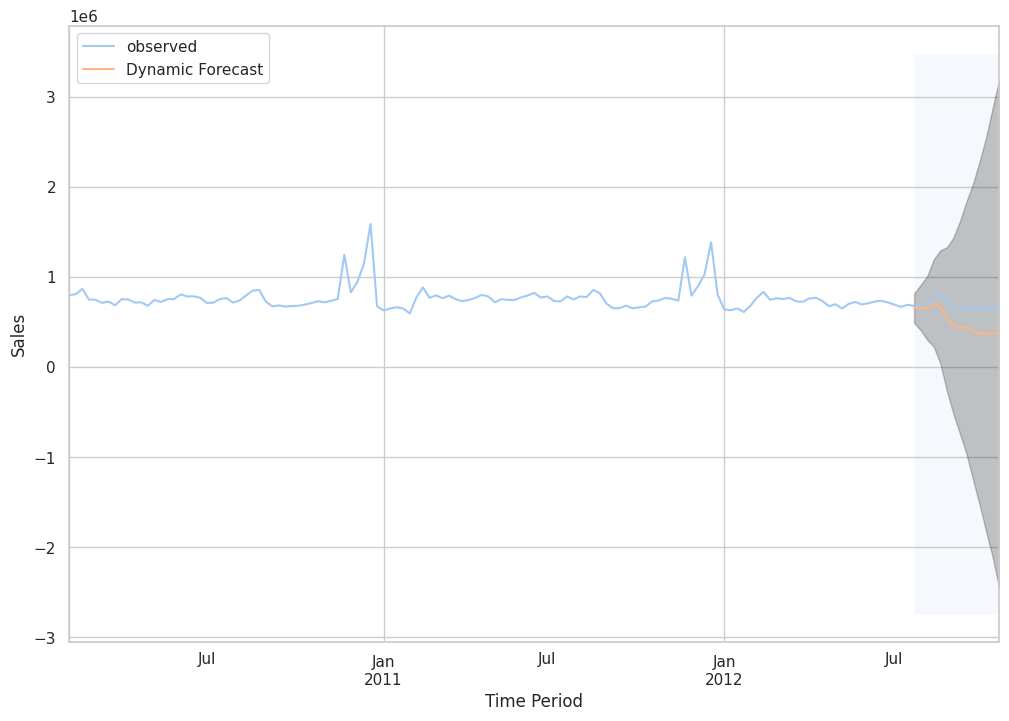

In [ ]:
pred_dynamic = results.get_prediction(start=pd.to_datetime('2012-7-27'), dynamic=True, full_results=True)
pred_dynamic_ci = pred_dynamic.conf_int()


ax = y1['2010':].plot(label='observed', figsize=(12, 8))
pred_dynamic.predicted_mean.plot(label='Dynamic Forecast', ax=ax)

ax.fill_between(pred_dynamic_ci.index,
                pred_dynamic_ci.iloc[:, 0],
                pred_dynamic_ci.iloc[:, 1], color='k', alpha=.25)

ax.fill_betweenx(ax.get_ylim(), pd.to_datetime('2012-7-26'), y1.index[-1],
                 alpha=.1, zorder=-1)

ax.set_xlabel('Time Period')
ax.set_ylabel('Sales')

plt.legend()
plt.show()

In [ ]:
#Extract the predicted and true values of time series
y_forecasted = pred_dynamic.predicted_mean
print(y_forecasted)

2012-07-27    652894.359524
2012-08-03    661405.734160
2012-08-10    655965.667593
2012-08-17    710544.193485
2012-08-24    667616.444290
2012-08-31    532255.739384
2012-09-07    458730.255853
2012-09-14    440822.702755
2012-09-21    437418.215285
2012-09-28    392882.524337
2012-10-05    378725.449945
2012-10-12    362316.643683
2012-10-19    384058.468792
2012-10-26    368859.377839
Freq: W-FRI, Name: predicted_mean, dtype: float64


In [ ]:
y_truth = y1['2012-7-27':]
print(y_truth)

Date
2012-07-27    677789.14
2012-08-03    693785.85
2012-08-10    700272.01
2012-08-17    751963.81
2012-08-24    802003.61
2012-08-31    763867.59
2012-09-07    642827.29
2012-09-14    628494.63
2012-09-21    667151.46
2012-09-28    647097.65
2012-10-05    651768.91
2012-10-12    653043.44
2012-10-19    641368.14
2012-10-26    675202.87
Name: Weekly_Sales, dtype: float64


In [ ]:
#computing rmse
rmse = np.sqrt(((y_forecasted - y_truth) ** 2).mean())
print('The Root Mean Squared Error of our forecasts is {}'.format(round(rmse, 2)))

The Root Mean Squared Error of our forecasts is 204012.5


In [ ]:
Residual= y_forecasted - y_truth
print("Residual for Store1",np.abs(Residual).sum())

Residual for Store1 2492140.6230745446


In [ ]:
#forecast
pred_uc = results.get_forecast(steps=12)
print(pred_uc)